In [1]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt

# Training data: f(x) = sin(2*pi*x)
X_train = np.linspace(0, 1, 5).reshape(-1, 1)
y_func = np.sin(2 * np.pi * X_train)
y_deriv = 2 * np.pi * np.cos(2 * np.pi * X_train)
y_train = [y_func, y_deriv]

# First-order derivative at all training points
der_indices = [[[[1, 1]]]]
derivative_locations = [[i for i in range(len(X_train))]]

# Dense test grid
X_test = np.linspace(0, 1, 200).reshape(-1, 1)
f_true = np.sin(2 * np.pi * X_test)
df_true = 2 * np.pi * np.cos(2 * np.pi * X_test)

print(f"Training points: {len(X_train)}, Test points: {len(X_test)}")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Training points: 5, Test points: 200


In [2]:
model_se = degp(X_train, y_train, n_order=1, n_bases=1,
                der_indices=der_indices,
                derivative_locations=derivative_locations,
                normalize=True,
                kernel="SE", kernel_type="anisotropic")

params_se = model_se.optimize_hyperparameters(
    optimizer='pso', pop_size=100, n_generations=15,
    local_opt_every=15, debug=False)

pred_se = model_se.predict(X_test, params_se, calc_cov=False, return_deriv=True)
print(f"SE -- Function RMSE: {np.sqrt(np.mean((pred_se[0,:] - f_true.flatten())**2)):.4e}")
print(f"SE -- Derivative RMSE: {np.sqrt(np.mean((pred_se[1,:] - df_true.flatten())**2)):.4e}")

Stopping: maximum iterations reached --> 15
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]
SE -- Function RMSE: 3.0232e-06
SE -- Derivative RMSE: 4.8618e-05


In [3]:
model_matern = degp(X_train, y_train, n_order=1, n_bases=1,
                    der_indices=der_indices,
                    derivative_locations=derivative_locations,
                    normalize=True,
                    kernel="Matern", kernel_type="anisotropic",
                    smoothness_parameter=2)

params_matern = model_matern.optimize_hyperparameters(
    optimizer='pso', pop_size=100, n_generations=15,
    local_opt_every=15, debug=False)

pred_matern = model_matern.predict(X_test, params_matern, calc_cov=False, return_deriv=True)
print(f"Matern -- Function RMSE: {np.sqrt(np.mean((pred_matern[0,:] - f_true.flatten())**2)):.4e}")
print(f"Matern -- Derivative RMSE: {np.sqrt(np.mean((pred_matern[1,:] - df_true.flatten())**2)):.4e}")

Stopping: maximum iterations reached --> 15
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]
Matern -- Function RMSE: 1.1303e-03
Matern -- Derivative RMSE: 1.6287e-02


In [4]:
model_rq = degp(X_train, y_train, n_order=1, n_bases=1,
                der_indices=der_indices,
                derivative_locations=derivative_locations,
                normalize=True,
                kernel="RQ", kernel_type="anisotropic")

params_rq = model_rq.optimize_hyperparameters(
    optimizer='pso', pop_size=100, n_generations=15,
    local_opt_every=15, debug=False)

pred_rq = model_rq.predict(X_test, params_rq, calc_cov=False, return_deriv=True)
print(f"RQ -- Function RMSE: {np.sqrt(np.mean((pred_rq[0,:] - f_true.flatten())**2)):.4e}")
print(f"RQ -- Derivative RMSE: {np.sqrt(np.mean((pred_rq[1,:] - df_true.flatten())**2)):.4e}")

Stopping: maximum iterations reached --> 15
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]
RQ -- Function RMSE: 3.0277e-06
RQ -- Derivative RMSE: 4.8583e-05


In [5]:
model_sine = degp(X_train, y_train, n_order=1, n_bases=1,
                  der_indices=der_indices,
                  derivative_locations=derivative_locations,
                  normalize=True,
                  kernel="SineExp", kernel_type="anisotropic")

params_sine = model_sine.optimize_hyperparameters(
    optimizer='pso', pop_size=100, n_generations=15,
    local_opt_every=15, debug=False)

pred_sine = model_sine.predict(X_test, params_sine, calc_cov=False, return_deriv=True)
print(f"SineExp -- Function RMSE: {np.sqrt(np.mean((pred_sine[0,:] - f_true.flatten())**2)):.4e}")
print(f"SineExp -- Derivative RMSE: {np.sqrt(np.mean((pred_sine[1,:] - df_true.flatten())**2)):.4e}")

Stopping: maximum iterations reached --> 15
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]]]
SineExp -- Function RMSE: 2.9161e-06
SineExp -- Derivative RMSE: 4.6950e-05


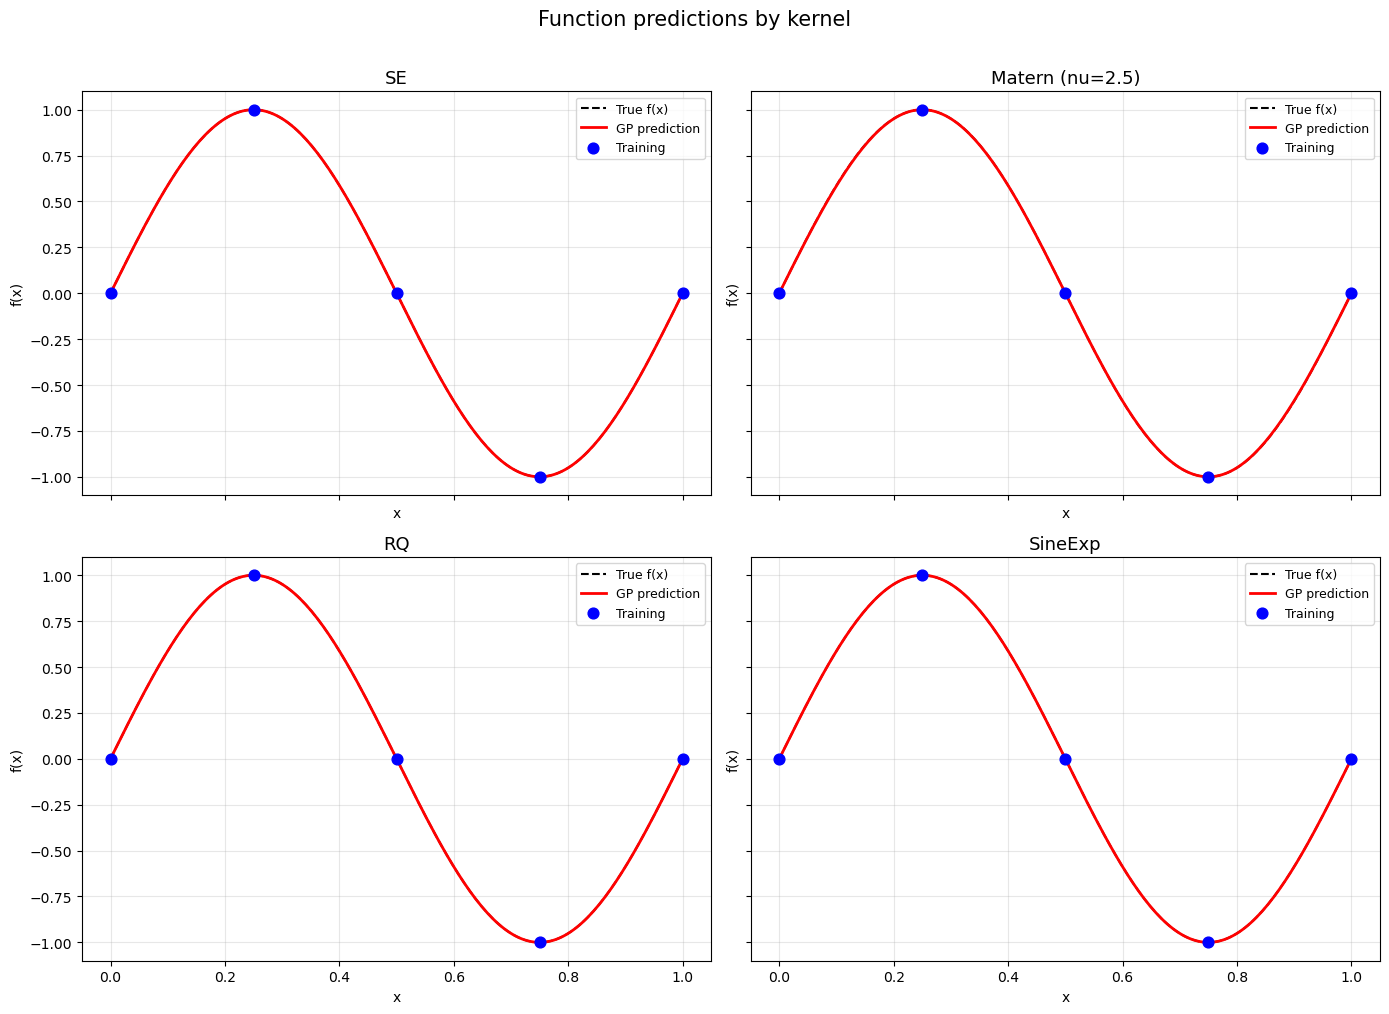

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

kernels = [
    ("SE", pred_se),
    ("Matern (nu=2.5)", pred_matern),
    ("RQ", pred_rq),
    ("SineExp", pred_sine),
]

for ax, (name, pred) in zip(axes.flat, kernels):
    ax.plot(X_test, f_true, 'k--', lw=1.5, label='True f(x)')
    ax.plot(X_test, pred[0, :], 'r-', lw=2, label='GP prediction')
    ax.scatter(X_train, y_func, c='blue', s=60, zorder=5, label='Training')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Function predictions by kernel', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

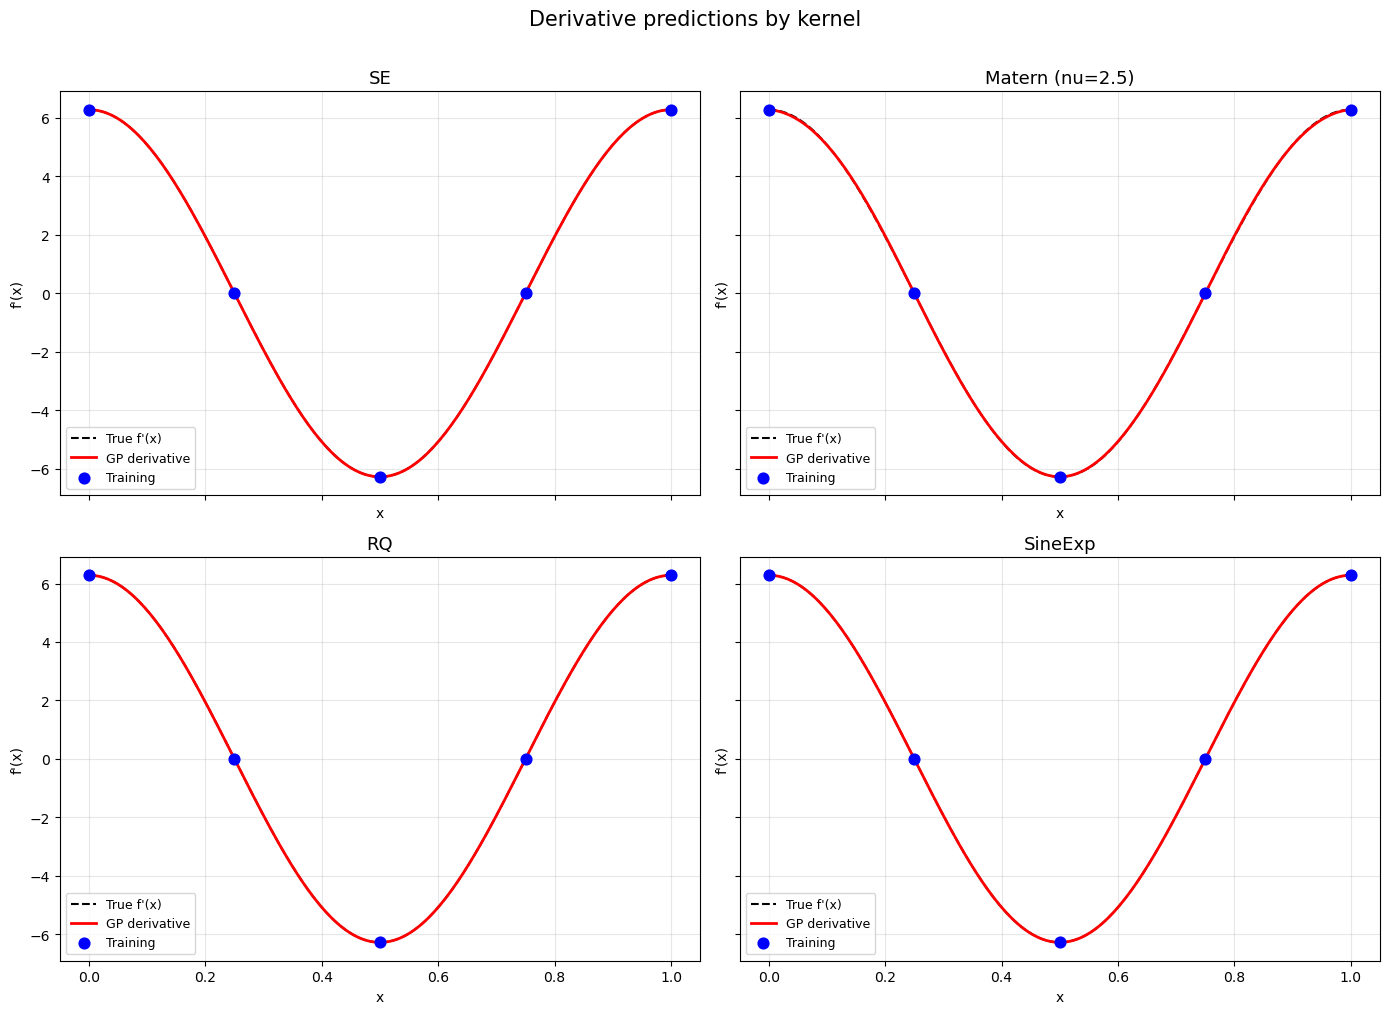

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, (name, pred) in zip(axes.flat, kernels):
    ax.plot(X_test, df_true, 'k--', lw=1.5, label="True f'(x)")
    ax.plot(X_test, pred[1, :], 'r-', lw=2, label='GP derivative')
    ax.scatter(X_train, y_deriv, c='blue', s=60, zorder=5, label='Training')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel("f'(x)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Derivative predictions by kernel', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
header = "{:<20} {:>15} {:>15}".format("Kernel", "f(x) RMSE", "f'(x) RMSE")
print("=" * 55)
print(header)
print("-" * 55)
for name, pred in kernels:
    rmse_f = np.sqrt(np.mean((pred[0, :] - f_true.flatten()) ** 2))
    rmse_d = np.sqrt(np.mean((pred[1, :] - df_true.flatten()) ** 2))
    print("{:<20} {:>15.4e} {:>15.4e}".format(name, rmse_f, rmse_d))
print("=" * 55)

Kernel                     f(x) RMSE      f'(x) RMSE
-------------------------------------------------------
SE                        3.0232e-06      4.8618e-05
Matern (nu=2.5)           1.1303e-03      1.6287e-02
RQ                        3.0277e-06      4.8583e-05
SineExp                   2.9161e-06      4.6950e-05


In [9]:
import numpy as np
from jetgp.full_degp.degp import degp
import matplotlib.pyplot as plt

def franke(X):
    x1, x2 = X[:, 0], X[:, 1]
    t1 = 0.75 * np.exp(-((9*x1 - 2)**2 + (9*x2 - 2)**2) / 4)
    t2 = 0.75 * np.exp(-(9*x1 + 1)**2 / 49 - (9*x2 + 1) / 10)
    t3 = 0.50 * np.exp(-((9*x1 - 7)**2 + (9*x2 - 3)**2) / 4)
    t4 = -0.20 * np.exp(-(9*x1 - 4)**2 - (9*x2 - 7)**2)
    return t1 + t2 + t3 + t4

def franke_dx1(X):
    x1, x2 = X[:, 0], X[:, 1]
    t1 = 0.75 * np.exp(-((9*x1-2)**2 + (9*x2-2)**2)/4) * (-2*(9*x1-2)*9/4)
    t2 = 0.75 * np.exp(-(9*x1+1)**2/49 - (9*x2+1)/10) * (-2*(9*x1+1)*9/49)
    t3 = 0.50 * np.exp(-((9*x1-7)**2 + (9*x2-3)**2)/4) * (-2*(9*x1-7)*9/4)
    t4 = -0.20 * np.exp(-(9*x1-4)**2 - (9*x2-7)**2) * (-2*(9*x1-4)*9)
    return t1 + t2 + t3 + t4

def franke_dx2(X):
    x1, x2 = X[:, 0], X[:, 1]
    t1 = 0.75 * np.exp(-((9*x1-2)**2 + (9*x2-2)**2)/4) * (-2*(9*x2-2)*9/4)
    t2 = 0.75 * np.exp(-(9*x1+1)**2/49 - (9*x2+1)/10) * (-9/10)
    t3 = 0.50 * np.exp(-((9*x1-7)**2 + (9*x2-3)**2)/4) * (-2*(9*x2-3)*9/4)
    t4 = -0.20 * np.exp(-(9*x1-4)**2 - (9*x2-7)**2) * (-2*(9*x2-7)*9)
    return t1 + t2 + t3 + t4

print("Franke function and gradients defined.")

Franke function and gradients defined.


In [10]:
np.random.seed(42)

# Training: 25 points on a 5x5 grid
g = np.linspace(0, 1, 5)
xx, yy = np.meshgrid(g, g)
X_train = np.column_stack([xx.ravel(), yy.ravel()])

y_func   = franke(X_train).reshape(-1, 1)
y_dx1    = franke_dx1(X_train).reshape(-1, 1)
y_dx2    = franke_dx2(X_train).reshape(-1, 1)
y_train  = [y_func, y_dx1, y_dx2]

# First-order partial derivatives at all training points
der_indices = [[[[1, 1]], [[2, 1]]]]
derivative_locations = [list(range(len(X_train))), list(range(len(X_train)))]

# Test: 30x30 grid
g_test = np.linspace(0, 1, 30)
xx_t, yy_t = np.meshgrid(g_test, g_test)
X_test = np.column_stack([xx_t.ravel(), yy_t.ravel()])
f_true = franke(X_test)

print(f"Training: {len(X_train)} points, Test: {len(X_test)} points")

Training: 25 points, Test: 900 points


In [11]:
kernel_configs = [
    ("SE",      "anisotropic", {}),
    ("SE",      "isotropic",   {}),
    ("Matern",  "anisotropic", {"smoothness_parameter": 2}),
    ("Matern",  "isotropic",   {"smoothness_parameter": 2}),
    ("RQ",      "anisotropic", {}),
    ("RQ",      "isotropic",   {}),
    ("SineExp", "anisotropic", {}),
    ("SineExp", "isotropic",   {}),
]

results = {}

for kern, ktype, extra_kw in kernel_configs:
    label = f"{kern} ({ktype[:5]})"
    print(f"Training {label} ...", end=" ")

    m = degp(X_train, y_train, n_order=1, n_bases=2,
             der_indices=der_indices,
             derivative_locations=derivative_locations,
             normalize=True,
             kernel=kern, kernel_type=ktype, **extra_kw)

    p = m.optimize_hyperparameters(
        optimizer='pso', pop_size=100, n_generations=15,
        local_opt_every=15, debug=False)

    pred = m.predict(X_test, p, calc_cov=False, return_deriv=False)
    rmse = np.sqrt(np.mean((pred.flatten() - f_true.flatten())**2))
    results[label] = {"pred": pred, "rmse": rmse, "params": p}
    print(f"RMSE = {rmse:.4e}")

Training SE (aniso) ... 

Stopping: maximum iterations reached --> 15
RMSE = 1.0447e-02
Training SE (isotr) ... 

Stopping: maximum iterations reached --> 15
RMSE = 1.0111e-02
Training Matern (aniso) ... 

Stopping: maximum iterations reached --> 15
RMSE = 7.3624e-03
Training Matern (isotr) ... 

Stopping: maximum iterations reached --> 15
RMSE = 7.0947e-03
Training RQ (aniso) ... 

Stopping: maximum iterations reached --> 15
RMSE = 8.3784e-03
Training RQ (isotr) ... 

Stopping: maximum iterations reached --> 15
RMSE = 7.9168e-03
Training SineExp (aniso) ... 

Stopping: maximum iterations reached --> 15
RMSE = 1.0151e-02
Training SineExp (isotr) ... 

Stopping: maximum iterations reached --> 15
RMSE = 1.0111e-02


In [12]:
print("=" * 45)
print(f"{'Kernel':<25} {'RMSE':>15}")
print("-" * 45)
for label in results:
    print(f"{label:<25} {results[label]['rmse']:>15.4e}")
print("=" * 45)

Kernel                               RMSE
---------------------------------------------
SE (aniso)                     1.0447e-02
SE (isotr)                     1.0111e-02
Matern (aniso)                 7.3624e-03
Matern (isotr)                 7.0947e-03
RQ (aniso)                     8.3784e-03
RQ (isotr)                     7.9168e-03
SineExp (aniso)                1.0151e-02
SineExp (isotr)                1.0111e-02


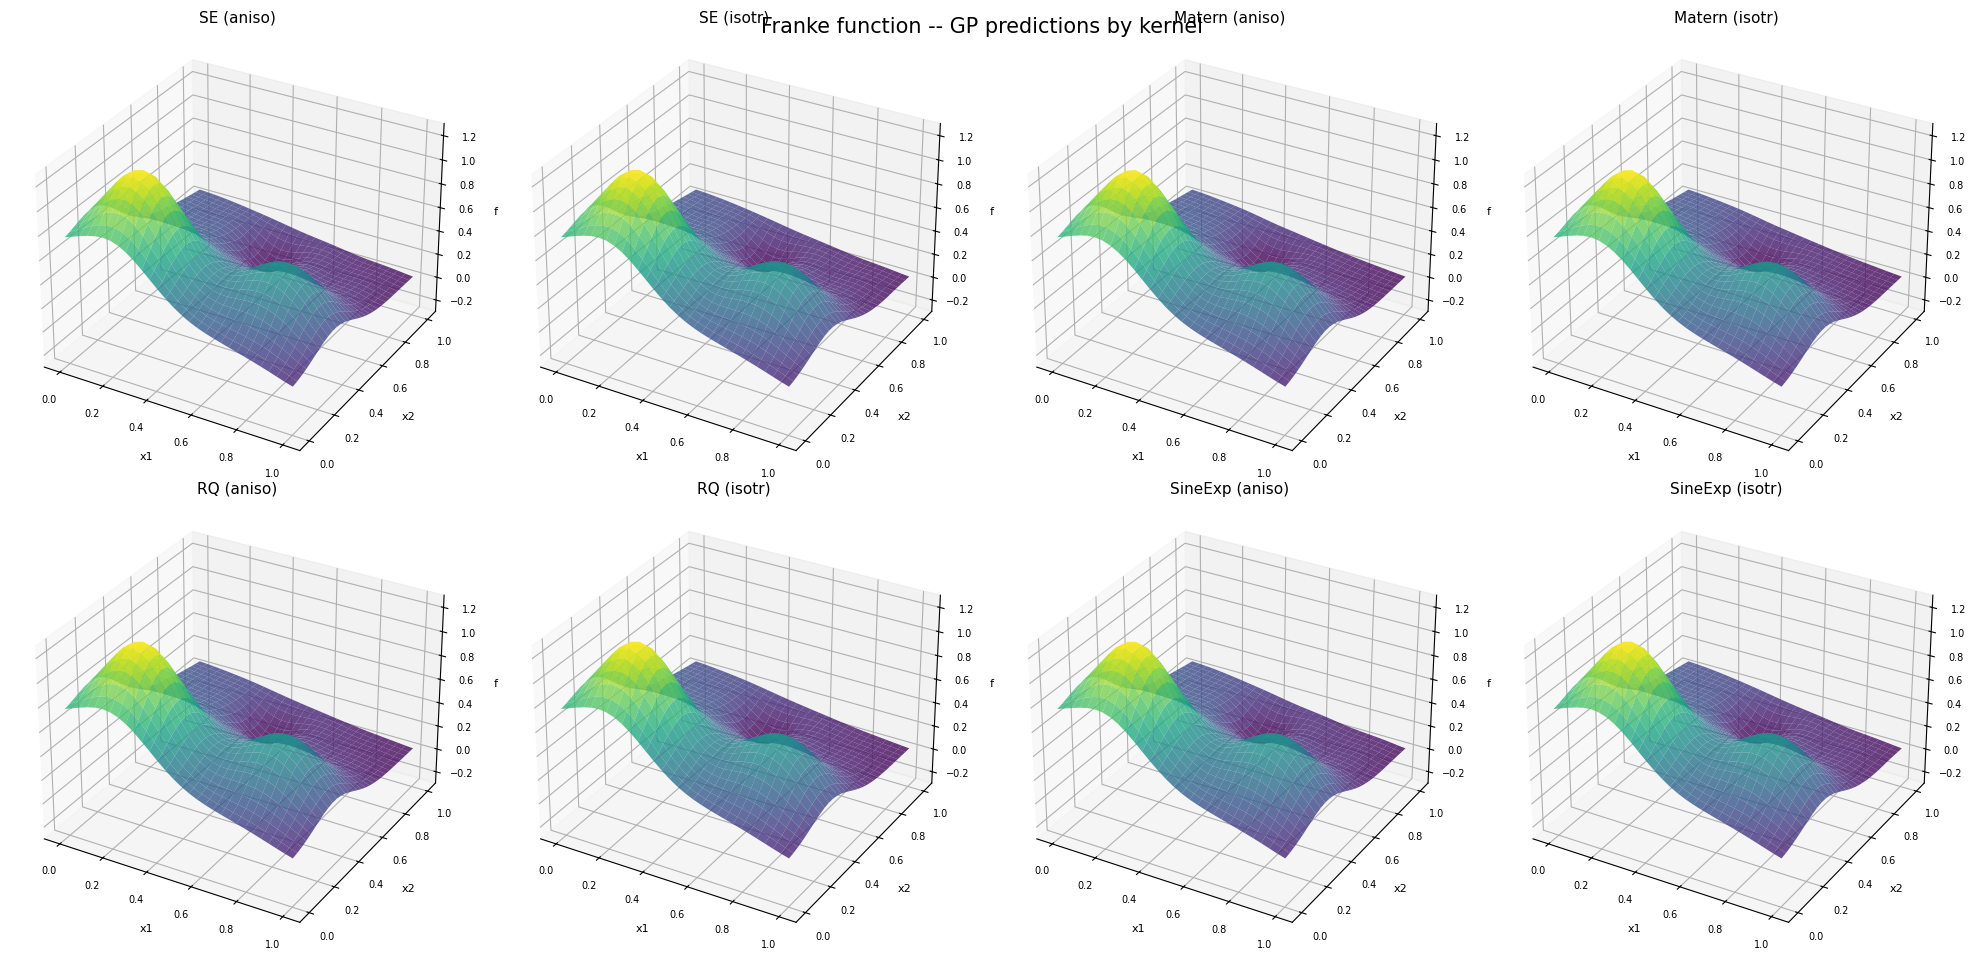

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10),
                         subplot_kw={'projection': '3d'})

labels = list(results.keys())

for idx, label in enumerate(labels):
    row, col = divmod(idx, 4)
    ax = axes[row, col]

    pred = results[label]["pred"]
    Z = pred.flatten().reshape(30, 30)

    ax.plot_surface(xx_t, yy_t, Z, cmap='viridis', alpha=0.8,
                    rstride=1, cstride=1, linewidth=0)
    ax.set_title(label, fontsize=11, pad=2)
    ax.set_xlabel('x1', fontsize=8)
    ax.set_ylabel('x2', fontsize=8)
    ax.set_zlabel('f', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_zlim(-0.3, 1.3)

plt.suptitle('Franke function -- GP predictions by kernel', fontsize=15, y=0.95)
plt.tight_layout()
plt.show()

/tmp/ipykernel_436148/1964130609.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


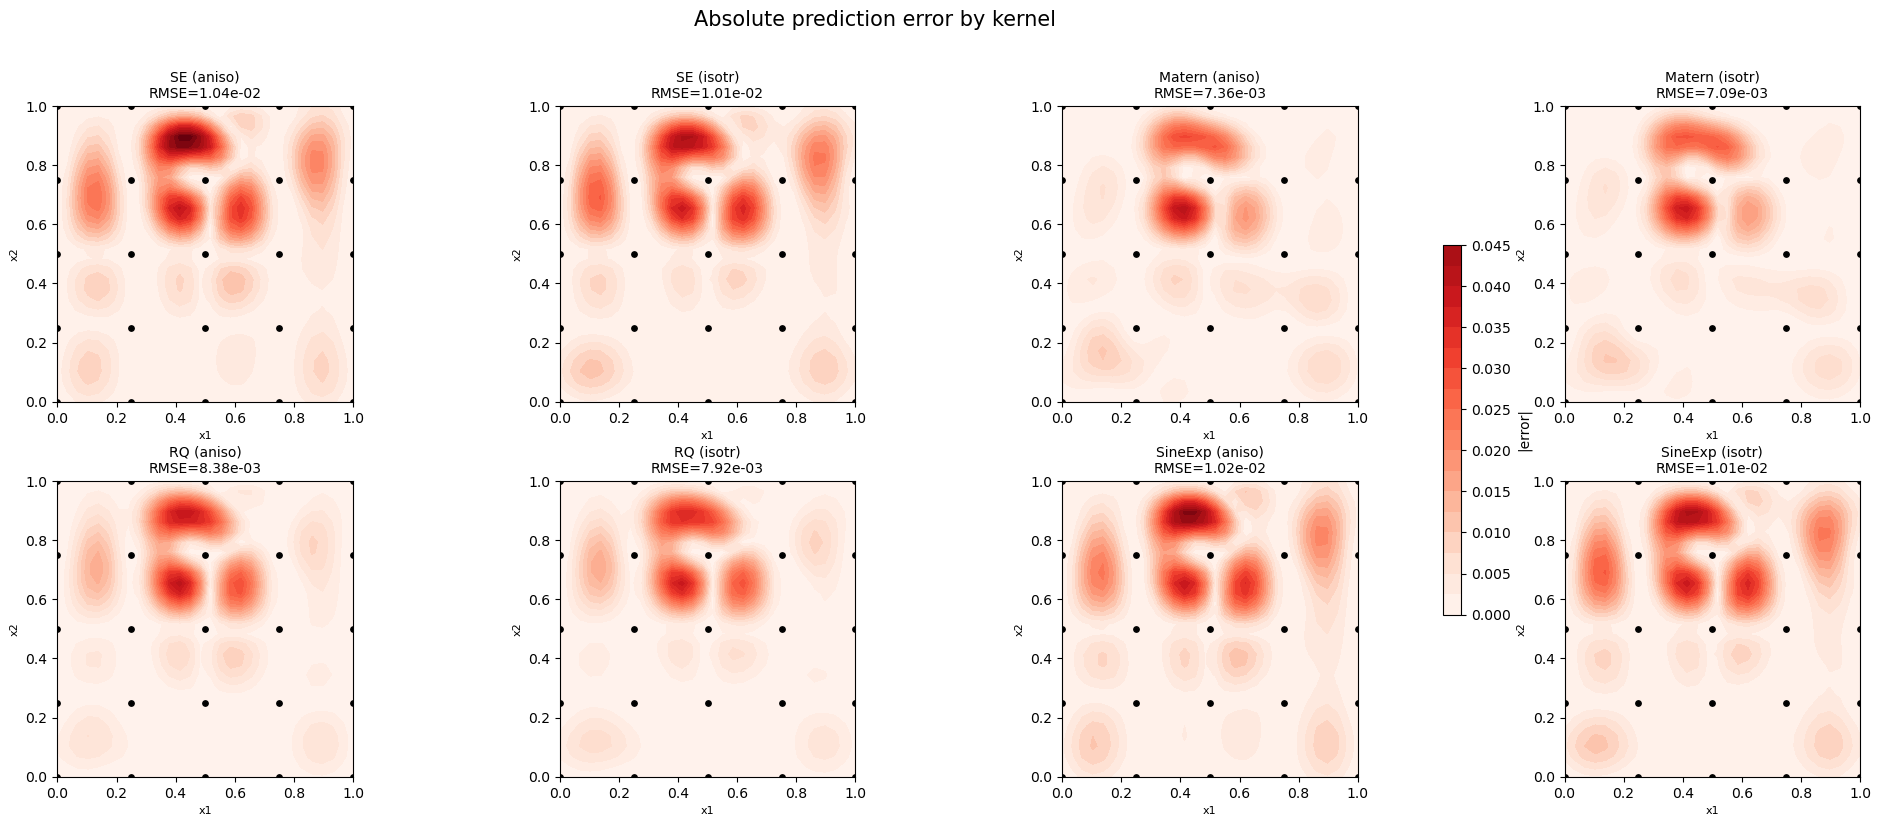

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
labels = list(results.keys())

# Shared color scale
max_err = max(
    np.max(np.abs(results[l]["pred"].flatten() - f_true.flatten()))
    for l in labels
)

for idx, label in enumerate(labels):
    row, col = divmod(idx, 4)
    ax = axes[row, col]

    err = np.abs(results[label]["pred"].flatten() - f_true.flatten()).reshape(30, 30)
    im = ax.contourf(xx_t, yy_t, err, levels=20, cmap='Reds', vmin=0, vmax=max_err)
    ax.scatter(X_train[:, 0], X_train[:, 1], c='black', s=15, zorder=5)
    ax.set_title(f"{label}\nRMSE={results[label]['rmse']:.2e}", fontsize=10)
    ax.set_xlabel('x1', fontsize=8)
    ax.set_ylabel('x2', fontsize=8)
    ax.set_aspect('equal')

fig.colorbar(im, ax=axes, label='|error|', shrink=0.6)
plt.suptitle('Absolute prediction error by kernel', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()